<a href="https://colab.research.google.com/github/sejal-oli7/python/blob/main/python%20/%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-09-17 12:28:14--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  --.-KB/s    in 0.09s   

2026-09-17 12:28:15 (15.2 MB/s) - ‘data.csv’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df['make'].str.lower().str.replace(' ', '_')

,make
0,bmw
1,bmw
2,bmw
3,bmw
4,bmw
...,...
11909,acura
11910,acura
11911,acura
11912,acura


In [7]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [8]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
df.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [11]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

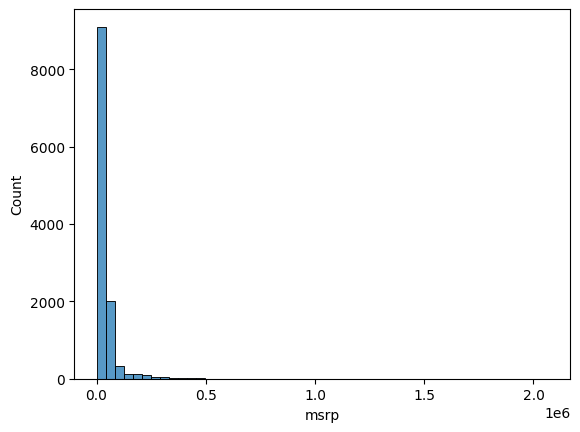

In [13]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

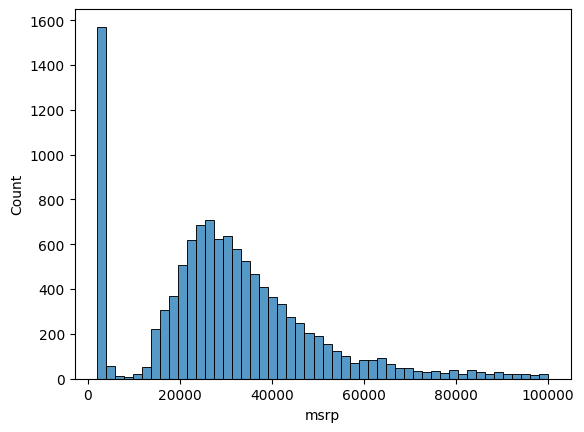

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

This left part of the histogram, there is a starge peak of cars that cost around 1000, probably the minimal price possible to put on the platform. Then the number of cards slowly grows up to around 25000, i.e almost 700 cars cost that much proce. and after that it foes down as the price grows.





This unsual distribution is not good for machine learning, the long tail will confuse the model and screw things up. Thus we want to get rid of it, and the usual trick is to apply the log function for that price.

In [15]:
df.isnull().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


Validation framework:

dataset is cleaned, explored, we need to split the dataset into train, validation and testing parts, we need to prepare the traget variable for each part. We do it manually using pandas and numpy

Calculating the size of the parts
- we will do 60/20/20 split, so we first need to calculate how many records 20% actually is. Our dataframe has almost 12k records, so 20% of that would be
approx 2400.  we want a whole number of records, not a fraction like 2382.58. Thus, we will cut the fraction off with int()

In [16]:
n = len(df)
n

11914

In [17]:
n_val = int(n*0.2)
n_test = int (n * 0.2)
# n_train = int(n * 0.6)
n_train = n - n_val - n_test

In [18]:
n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

**Taking a part of the dtaframe with iloc**
Now, we know the sizes, and we need to take a part of the dataframe of that size.  For that we use ```iloc```, which we have already studied.
we usually give it a list of indices, but it also accespts range.
eg to get first 10 records

In [19]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


Take away: i used range, it gives 10 records, inclusive of record 0 but exclusive of record 10.

So the simplest thing we can do is cut the dataframe sequentially

In [20]:
df.head(20)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [21]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val + n_test]
df_train = df.iloc[n_val + n_test:]

we noticed here, while splitting sequentially, the dataset is being filtered by the column name, make. So, we validation contains only bmw, training contains only one specific car, and same for testing. which is a red flag.

Thats the reason, ALWAYS, SHUFFLE THE DATASET BEFORE YOU PASS IT FOR MODEL TRAINING

We need to shuffle the dataset,  we can use np.random.shuffle

In [22]:
n, n_train, n_val, n_test

(11914, 7150, 2382, 2382)

In [23]:
idx = np.arange(n)
np.random.shuffle(idx)

In [24]:
#@ Now, we index the dataframe with the shuffled numbers instead of sequential ranges

In [25]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

Still theres a problem??????
The problem is, everytime, you run this code,
 you will get a new random data for each df_train,test, val.

 you will end of developing a model under this condition, when the model accuracy is not satified, you need to retrain the model with tweaked parameter. But this time, when you split, again the data is shuffled, that means, you wont be able to get the same data that have been used previously

In [26]:
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [27]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [28]:
len(df_train), len(df_val), len(df_test)


(7150, 2382, 2382)

In [29]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


looking at the dataset, we encountered that, the index of the dataframe is also shuffled, we can reset the index for this scenario

In [30]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [31]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


So far, we have completed data cleaning and made it ready for model training

- our task was to predict the price of a car

We will start with very basic model, call it as linear regression model.

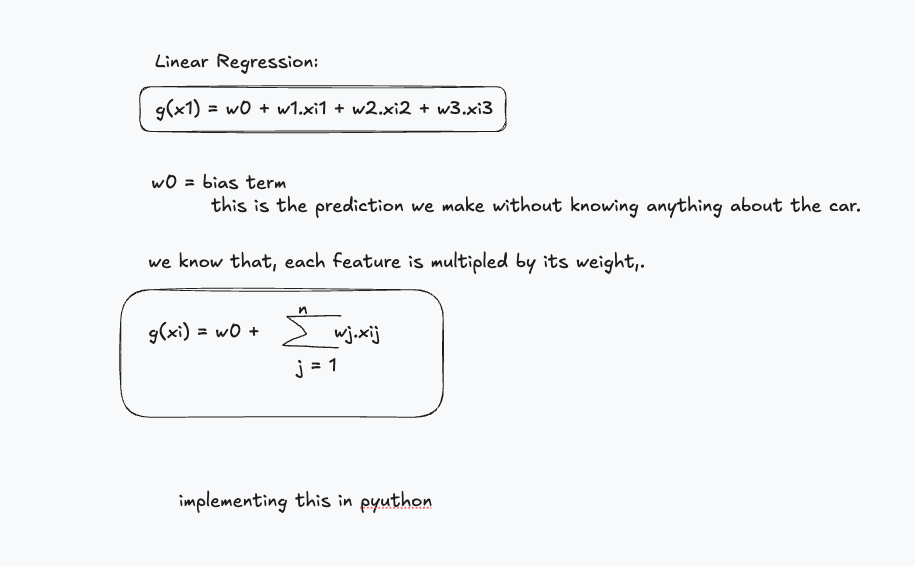

In [45]:
#@ We have feature vector xi, the bias term, w0 and a vector w with a weight for each feature

xi = [132 ,25, 2031]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [46]:
#@ Lets create a function to implement the above output function
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j] # pred = w0 + 0.01 * 453

    return pred

In [47]:
#@ Lets apply this mathematics to our car

linear_regression(xi)

13.552

In [48]:
np.expm1(13.552)

np.float64(768348.5101897252)

In [35]:
7.17 + 453*0.01 + 11*0.04 + 86*0.002

12.312

Lets implement linear regression in our system


In [36]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


Preparing y and removing msrp:

the df will be used to make the feature matrix X, The target y comes from the msrp column and we already know that we need to apply some mathematical function, to handle its distribution.

### Linear Regression

## 1. Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value.

Example:

* Predict salary from experience.
* Predict house price from house size.

### Simple Linear Regression

It uses **one independent variable (X)** to predict one dependent variable (Y).

### Main Formula:

**Ŷ = b₀ + b₁X**

Where:

* **Ŷ** = Predicted value of Y
* **b₀** = Intercept
* **b₁** = Slope/Coefficient
* **X** = Independent variable

### Intercept Formula:

**b₀ = Ȳ − b₁X̄**

### Slope Formula:

**b₁ = Σ(Xᵢ − X̄)(Yᵢ − Ȳ) / Σ(Xᵢ − X̄)²**

Where:

* **X̄** = Mean of X
* **Ȳ** = Mean of Y
* **Xᵢ** = Individual X value
* **Yᵢ** = Individual Y value
* **Σ** = Sum of all values

### Simple Example:

If:

**Ŷ = 10 + 2X**

and **X = 5**

Then:

**Ŷ = 10 + 2(5)**

**Ŷ = 20**

Therefore, predicted Y = **20**.





# 2. Multiple Linear Regression

Multiple Linear Regression is used when there are **two or more independent variables** to predict one dependent variable.

### Formula:

**Ŷ = b₀ + b₁X₁ + b₂X₂ + b₃X₃ + ... + bₙXₙ**

Where:

* **Ŷ** = Predicted value
* **b₀** = Intercept
* **b₁, b₂, b₃...bₙ** = Coefficients
* **X₁, X₂, X₃...Xₙ** = Independent variables

### Example:

Suppose we want to predict salary using:

* X₁ = Experience
* X₂ = Education
* X₃ = Age

Regression equation:

**Ŷ = 10 + 2X₁ + 3X₂ − X₃**

If:

**X₁ = 5, X₂ = 2, X₃ = 4**

Then:

**Ŷ = 10 + 2(5) + 3(2) − 4**

**Ŷ = 10 + 10 + 6 − 4**

**Ŷ = 22**

Therefore, predicted value = **22**.

# 3. Difference

| Simple Linear Regression        | Multiple Linear Regression                         |
| ------------------------------- | -------------------------------------------------- |
| Uses one X variable             | Uses two or more X variables                       |
| Ŷ = b₀ + b₁X                    | Ŷ = b₀ + b₁X₁ + b₂X₂ + ...                         |
| Example: Salary from experience | Example: Salary from experience, education and age |

## Important Terms

**Dependent Variable (Y):** The value we want to predict.

**Independent Variable (X):** The variable used to predict Y.

**Intercept (b₀):** Value of Y when X is 0.

**Slope/Coefficient (b₁):** Shows how much Y changes when X changes by one unit.

**Prediction (Ŷ):** The value predicted by the regression model.

**Error/Residual:**

**Error = Actual Value − Predicted Value**

## Main Formulas to Remember

**Simple Linear Regression:**

**Ŷ = b₀ + b₁X**

**Slope:**

**b₁ = Σ(Xᵢ − X̄)(Yᵢ − Ȳ) / Σ(Xᵢ − X̄)²**

**Intercept:**

**b₀ = Ȳ − b₁X̄**

**Multiple Linear Regression:**

**Ŷ = b₀ + b₁X₁ + b₂X₂ + ... + bₙXₙ**


In [37]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [39]:
y_train = np.log1p(df_train.msrp.values)
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978])

In [40]:
np.expm1(9.57574708,)

np.float64(14409.999959096362)

In [41]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [42]:
# del df_train['msrp']
# del df_val['msrp']
# del df_test['msrp']

## Linear Regression

In [50]:
xi = [453, 11, 86] # 453 horse power, 11:mileage per gallon, 86 popularity score of 10 th record,
w0 = 7.17 # bias
w = [0.01, 0.04, 0.002] #weights
# w0 and w are assumptions for the above car rolce royes

we can also represent the above expression for g(xi) in the forms of vectors

``` g(xi) = w0 + xi^Tw ```

In [52]:
#@ If we apply this compact notation in our system

def dot(xi, w):
  n = len(xi)

  res = 0.0

  for j in range(n):
    res = res + xi[j] * w[j]

  return res

In [53]:
#@ Now implementing  linear regression function

def linear_regression(xi):
  return w0 + dot(xi, w)

 To make it even shorter

 ```w = [w0 w1 w2 ...... wn] n+1 dim ```
``` xi =[xi0 xi1 xi2 .....xin] ```

 xio= 1

wT Xi = XiTw

In [54]:
# Xi = Xi0 +Xi
# Xi0 = 1

#Xi = [1] + Xi

We can make a feature in a way that

we will have new values of w and Xi

In [55]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

similarly, we can also prepend 1 to xi and then taking dot product of these two vectors xi and w like below

In [56]:
def linear_regression(xi):
  xi =[1] + xi
  return dot(xi,w_new)